In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset 
import matplotlib.pyplot as plt

# Loading Data 
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [4]:
# Loading Data from CSV
df_US_software_pivot =pd.read_csv("https://lukeb.co/software_csv", index_col='job_posted_month')
df_US_software_pivot


,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [8]:
# Filtering Data for United States - creating new unique dataframe for US jobs only
df_US = df[df['job_country'] == 'United States'].copy()

# Creating a new column for the month of job posting
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')

# Creating a pivot table to analyze the number of job postings by month and job title
df_US_pivot =df_US.pivot_table(index='job_posted_month',columns='job_title_short', aggfunc='size')

# Resetting the index of the pivot table to make 'job_posted_month' a column instead of an index
df_US_pivot.reset_index(inplace = True)

# Creating a new column for the month number to sort the pivot table by month
df_US_pivot['month_no'] = pd.to_datetime(df_US_pivot['job_posted_month'], format='%B').dt.month

# Sorting the pivot table by month number and setting 'job_posted_month' as the index
df_US_pivot.sort_values(by='month_no', inplace=True)
df_US_pivot.set_index('job_posted_month', inplace=True)

# Dropping the 'month_no' column as it is no longer needed after sorting
df_US_pivot.drop(columns='month_no', inplace=True)

In [11]:
# Merging the two pivot tables on 'job_posted_month' to combine the data for analysis
df_US_merged =df_US_pivot.merge(df_US_software_pivot, on='job_posted_month')
df_US_merged

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,13619,9827,5108,4348
February,447,24,6124,3060,4956,56,1258,878,1127,90,11456,9116,7298,4284
March,438,19,6218,3183,4779,59,1114,829,1150,115,11102,8178,5814,4159
April,565,40,6049,2801,4867,51,1025,781,991,112,14037,9209,7232,4220
May,279,20,4993,2976,4377,49,839,746,914,90,12126,8864,6718,4980
June,446,32,5683,2893,4645,48,1009,812,1033,93,12003,8065,5902,4781
July,581,39,5201,2570,4876,65,883,747,1095,153,11914,8061,6839,4344
August,903,39,6634,3269,6318,68,1186,903,1515,194,11571,8191,7413,4104
September,897,50,4639,3224,4568,113,805,775,1014,228,14016,8447,6139,4094


In [16]:
# Identifying the top 5 job titles with the highest number of postings in the United States
top_5 = (
    df_US_merged
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.to_list()
)
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

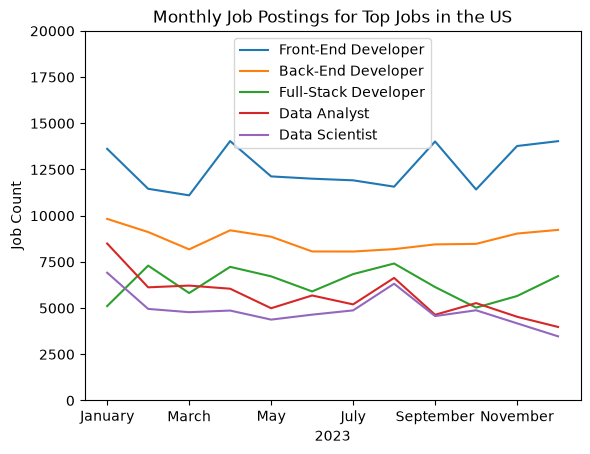

In [20]:
# Plotting the top 5 job titles with the highest number of postings in the United States over time
df_US_merged[top_5].plot(kind='line')
plt.title("Monthly Job Postings for Top Jobs in the US")
plt.xlabel("2023")
plt.ylabel("Job Count")
plt.ylim(0, 20000)
plt.legend()
plt.legend()
plt.show()